# The Price of Crash Insurance — a quantitative teardown 🔬
### HAC drift · alpha-vs-collateral decomposition (daily / monthly / sub-periods) · the 2020 episode · buyer-side variance premium from ^VIX+SPY · cohort accounting · blend costs · a 20-seed fair-vs-planted-bleed control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![2020 win kept?: Busted](https://img.shields.io/badge/2020_win_kept%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **crash insurance bleeds every year, and the bleed is the volatility risk premium from the buyer's side** — is *likely true by construction*, so the job is to measure it honestly on the live product (TAIL) and pin the mechanism.

> ⚠️ **Data note.** yfinance daily closes: TAIL/IEF/SPY **auto-adjusted total-return**, ^VIX a **level**. TAIL numbers are **net of its 0.59%/yr ER** (inside the NAV). TAIL buy-and-hold is static — no signal, no lag; the variance-premium series uses strictly prior-month VIX (one documented one-month lag). Survivorship runs *against* the claim (TAIL is the surviving tail fund; the dead ones bled faster). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `c3658cfa4e95`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crash_insurance_cost import data, strategy as st

HAVE_REAL = data.have_real()
TAPE = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL, "| rows:", 0 if TAPE is None else len(TAPE))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': 'c3658cfa4e95', 'start': '2017-04-06', 'end': '2026-06-30', 'years': 9.2, 'n_days': 2319, 'n_months': 110, 'total_pct': -49.7, 'cagr_pct': -7.17, 'vol_pct': 14.8, 'daily_bps': -2.53, 'daily_t': -1.49, 'monthly_bps': -56.52, 'monthly_t': -2.17, 'alpha_d_bps': -3.08, 'alpha_d_ann': -7.75, 'alpha_d_t': -1.98, 'beta_d': 1.05, 'r2_d': 0.226, 'alpha_m_bps': -64.09, 'alpha_m_ann': -7.69, 'alpha_m_t': -3.28, 'beta_m': 0.73, 'pre_ann': -14.7, 'pre_t': -2.5, 'post_ann': -8.07, 'post_t': -1.75, 'covid_gain': 28.47, 'covid_peak': '2020-04-02', 'spy_fall': -33.72, 'giveback': '2021-03-05', 'giveback_days': 337, 'holder_peak': 4.22, 'holder_now': -49.67, 'vrp_start': '1993-02', 'vrp_end': '2026-06', 'vrp_months': 401, 'vrp_var': -0.95, 'vrp_var_t': -3.12, 'vrp_vol': -3.79, 'vrp_vol_t': -9.42, 'vrp_win': 16.2, 'iv': 20.98, 'rv': 18.58, 'vrp_era_var': -0.67, 'vrp_era_var_t': -1.06, 'vrp_era_vol': -3.62, 'vrp_era_vol_t': -4.44, 'n_cohorts': 110, 'ahead_now': 1, 'ahead_share': 0.9, 'best': 0.1, 'best_date': '2025-01-31', 'median': -34.1, 'worst': -49.4, 'ever_ahead': 71.8, 'blends': [(5, 14.06, 15.12, 1.06, -22.9, -23.9, -17.6, -19.4), (10, 12.99, 15.12, 2.13, -21.9, -23.9, -15.8, -19.4), (20, 10.84, 15.12, 4.28, -19.9, -23.9, -12.1, -19.4)], 'ctrl': [(0.0, -0.21, -0.31, 5.0), (5.0, -5.21, -5.81, 100.0)]}


real cache present: True | rows: 9191


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Monthly drift **-56.5 bps/mo** (HAC **t = -2.17**); monthly alpha vs IEF **-7.69%/yr** (HAC **t = -3.28**), negative in both crash-free sub-periods; buyer-side variance premium over 401 months: RV−IV t = **-3.12** (vol-points t = -9.42), buyer wins 16% of months. |
| **Tradability** | `MIRAGE` | No deployable long-side edge: $1 → $0.50 net; SPY/TAIL blends drag CAGR 1.1–4.3 pp/yr at 5 bps; the 2020 jackpot was given back in 337 days. The premium's harvestable side is the seller's (studies 92 / 63). |
| **2020 win kept?** | `BUSTED` | 1 of 110 cohorts above water (+0.1%, a 2025 entry); 72% were ever ahead and all gave it back; day-one holder peaked at +4.2%. |

> 💡 In plain words: the bleed is real, measured three independent ways — and it is exactly the premium the desk's short-vol studies collect.

## 1 · The claim, steelmanned

Let $r^{TAIL}_t$ be TAIL's daily total return and $r^{IEF}_t$ its collateral proxy's. The design ($\approx$ 90% intermediate Treasuries + an OTM SPX put ladder) implies

$$r^{TAIL}_t = \alpha + \beta\, r^{IEF}_t + \varepsilon_t,$$

where $\alpha$ captures the put sleeve **plus the fee** — the insurance bill, isolated from duration. The claim decomposes into:

- **H₁ (the bleed exists).** $\alpha < 0$ and HAC-significant; raw drift negative.
- **H₂ (the bleed is the VRP).** The buyer-side variance premium $\mathbb{E}[RV - IV] < 0$ on real ^VIX+SPY, same sign and magnitude class.
- **H₃ (the jackpot doesn't redeem it).** Net of 2020, no entry cohort ends ahead.

We find **all three supported** — H₁ at monthly HAC t = -3.28, H₂ at t = -3.12 over 33 years, H₃ with 1/110 cohorts ahead.

## 2 · So what? — what rides on each answer

The volatility risk premium is the desk's most-replicated finding from the **short** side ([92-easy-money](../../92-easy-money/): short VIXY carry, HAC t = +2.31; [63-free-fall](../../63-free-fall/): SVXY carry — both `Real`). If a live *long-vol* product bleeds at a compatible rate, the premium is confirmed **from both ends of the pipe** — the cleanest possible triangulation, on tradable NAVs rather than model surfaces. And the buyer's side is where retail actually lives: the 2020 spike chart sells tail funds; the annual bill is the part the chart doesn't show.

Inference discipline: HAC/Newey-West t on every serially-correlated mean (plug-in lag $\lfloor 4(n/100)^{2/9}\rfloor$); monthly frequency as the headline for the decomposition (daily microstructure noise dilutes t); crash-free sub-periods so no leg owes its sign to the jackpot; the variance series uses **strictly prior** month-end VIX.

## 3 · How we'd know — the protocol

- **Tape.** yfinance TAIL/IEF/SPY (total-return) + ^VIX (level), TAIL era 2017-04-06 → 2026-06-30 (2319 daily returns, 110 complete months), as-of 2026-06-30, fingerprint `c3658cfa4e95`.
- **H₁.** HAC t of the raw drift (daily + monthly); OLS of TAIL on IEF with HAC t on $\alpha$ (daily, monthly, pre-COVID → 2020-02-19, post-COVID 2020-07-01 →).
- **H₂.** Monthly $RV_m = \sum_d \ln^2(S_d/S_{d-1})$ vs $IV_m = (VIX_{m-1}/100)^2/12$ (prior month-end — one clean lag); HAC t of the mean in variance and vol-point units; 1993→ and TAIL-era windows. **Model arithmetic on real tapes, labeled** — no strikes, no roll mechanics.
- **H₃.** Every month-end entry cohort held to as-of; ever-ahead vs ahead-now.
- **Costs.** SPY/TAIL blends: monthly rebalance, 5 bps one-way × turnover; TAIL ER inside NAV.
- **Control.** Synthetic bond+put world with a planted net bleed, **20 seeds per setting**: fair insurance (bleed 0) must not be flagged; a planted 5%/yr bleed must be recovered in size and t.

## 4 · The teardown

### 4a · The bleed, measured — drift and the alpha-vs-collateral decomposition

Raw drift first, then the regression that separates the puts from the bonds.

drift   : total -49.7%  CAGR -7.17%/yr  vol 14.8%
          daily -2.53 bps (HAC t -1.49)   monthly -56.52 bps (HAC t -2.17, n=110)
alpha   : daily -7.75%/yr (t -1.98, beta 1.05, R2 0.226)
          monthly -7.69%/yr (t -3.28, beta 0.73) <- headline
          pre-COVID -14.70%/yr (t -2.50)   post-COVID -8.07%/yr (t -1.75)


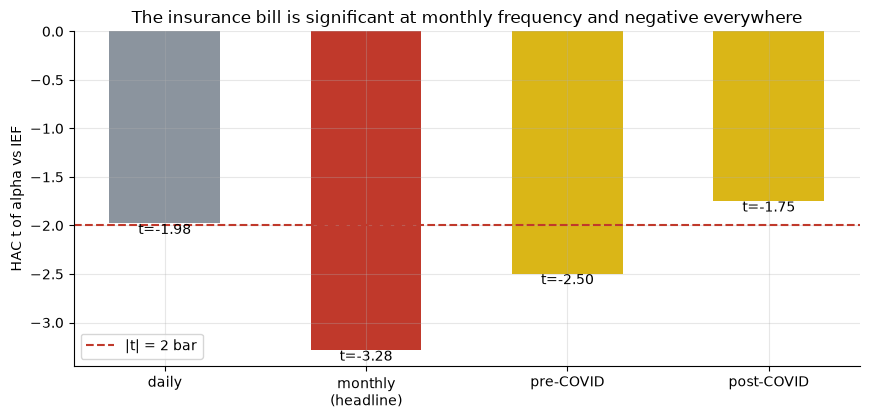

In [2]:
if HAVE_REAL:
    d = st.drift_stats(TAPE); dd = st.decompose_vs_ief(TAPE); dm = st.decompose_monthly(TAPE)
    sp = st.alpha_subperiods(TAPE)
    print(f"drift   : total {d['total_pct']:+.1f}%  CAGR {d['cagr_pct']:+.2f}%/yr  vol {d['ann_vol_pct']:.1f}%")
    print(f"          daily {d['daily_mean_bps']:+.2f} bps (HAC t {d['daily_t']:+.2f})   "
          f"monthly {d['monthly_mean_bps']:+.2f} bps (HAC t {d['monthly_t']:+.2f}, n={d['n_months']})")
    print(f"alpha   : daily {dd['alpha_ann_pct']:+.2f}%/yr (t {dd['t_alpha']:+.2f}, beta {dd['beta_ief']:.2f}, R2 {dd['r2']:.3f})")
    print(f"          monthly {dm['alpha_ann_pct']:+.2f}%/yr (t {dm['t_alpha']:+.2f}, beta {dm['beta_ief']:.2f}) <- headline")
    print(f"          pre-COVID {sp['pre']['alpha_ann_pct']:+.2f}%/yr (t {sp['pre']['t_alpha']:+.2f})   "
          f"post-COVID {sp['post']['alpha_ann_pct']:+.2f}%/yr (t {sp['post']['t_alpha']:+.2f})")
    labels = ['daily', 'monthly\n(headline)', 'pre-COVID', 'post-COVID']
    tvals = [dd['t_alpha'], dm['t_alpha'], sp['pre']['t_alpha'], sp['post']['t_alpha']]
else:
    labels = ['daily', 'monthly\n(headline)', 'pre-COVID', 'post-COVID']
    tvals = [R['alpha_d_t'], R['alpha_m_t'], R['pre_t'], R['post_t']]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(labels, tvals, color=[GREY, RED, AMBER, AMBER], width=.55)
ax.axhline(-2, ls='--', c=RED, label='|t| = 2 bar')
for i, v in enumerate(tvals): ax.annotate(f't={v:.2f}', (i, v), ha='center', va='top')
ax.set_ylabel('HAC t of alpha vs IEF'); ax.legend()
ax.set_title('The insurance bill is significant at monthly frequency and negative everywhere')
plt.tight_layout(); plt.show()

> 💡 In plain words: strip the bond sleeve out and the puts + fee cost **-7.7%/yr** — significant (**t = -3.28**) at the monthly frequency where compounding soaks up daily noise, and negative both **before** COVID (-14.7%/yr, t = -2.50) and **after** it (-8.1%/yr, t = -1.75) — the crash itself excluded from both legs, so no sub-period owes its sign to the jackpot. The raw monthly drift clears the bar on its own (t = -2.17).

### 4b · The premium named — RV − IV on real ^VIX + SPY, 1993 →

The buyer of one month of variance pays $(VIX_{m-1}/100)^2/12$ and receives the month's realized variance. Cumulate the buyer's P&L:

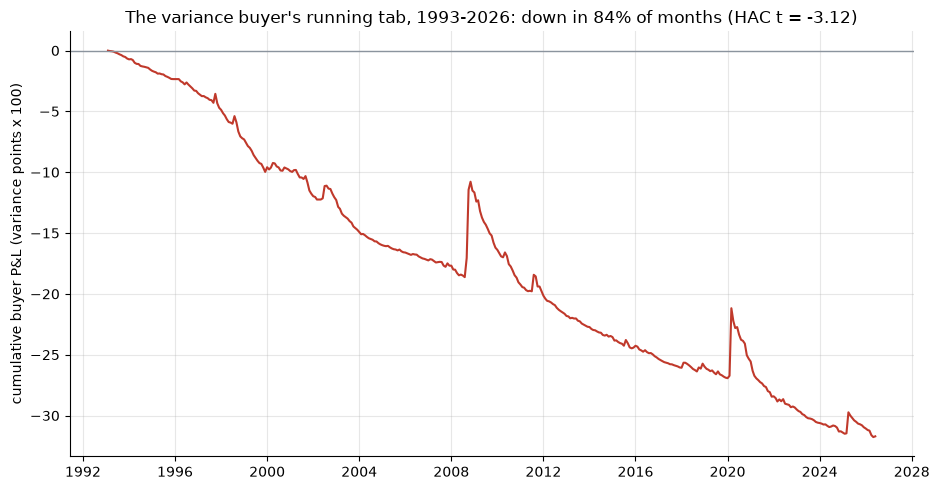

RV-IV -0.95 var pts/yr (t -3.12)  vol-pts -3.79 (t -9.42)
implied 20.98% vs realized 18.58%  buyer wins 16.2% of 401 months


In [3]:
if HAVE_REAL:
    vix = TAPE['vix'].dropna(); spy = TAPE['spy'].dropna()
    lr = np.log(spy / spy.shift(1)).dropna()
    rv = (lr**2).groupby(lr.index.to_period('M')).sum()
    iv = ((vix.resample('ME').last()/100.0)**2/12.0); iv.index = iv.index.to_period('M')+1
    pnl = (rv - iv).dropna(); pnl = pnl[pnl.index >= pd.Period('1993-02','M')]
    cum = pnl.cumsum() * 100
    vp = st.variance_premium(TAPE)
    fig, ax = plt.subplots()
    ax.plot(cum.index.to_timestamp(), cum.values, color=RED, lw=1.5)
    ax.axhline(0, color=GREY, lw=1)
    ax.set_ylabel('cumulative buyer P&L (variance points x 100)')
    ax.set_title(f"The variance buyer's running tab, 1993-2026: down in {100-vp['share_buyer_wins']:.0f}% of months (HAC t = {vp['t_var']:.2f})")
    plt.tight_layout(); plt.show()
    print(f"RV-IV {vp['mean_var_ann']*100:+.2f} var pts/yr (t {vp['t_var']:+.2f})  vol-pts {vp['mean_vol_pts']:+.2f} (t {vp['t_vol']:+.2f})")
    print(f"implied {vp['iv_ann_vol']:.2f}% vs realized {vp['rv_ann_vol']:.2f}%  buyer wins {vp['share_buyer_wins']:.1f}% of {vp['n_months']} months")
else:
    print('cache missing - frozen:', R['vrp_var'], 'var pts (t', R['vrp_var_t'], '), buyer wins', R['vrp_win'], '%')

> 💡 In plain words: for 33 years the market has quoted insurance at **21.0%** vol and delivered **18.6%** — the buyer pays the gap, loses in **5 months out of 6**, and the mean is solidly nonzero (t = -3.12 in variance units, -9.42 in vol points). Within the shorter TAIL era the variance-unit t drops below 2 (-1.06 — nine years is short for a crash-skewed series) while vol-points stay clear (-4.44); the 33-year window is the honest estimate of the premium itself. *(Model arithmetic on real tapes — labeled; no strikes, no roll mechanics. TAIL's alpha is the live-product evidence.)*

### 4c · The 2020 episode + cohort accounting — H₃

The jackpot, end-to-end, and every month-end buyer's final ledger.

2020: TAIL +28.47% (to 2020-04-02) while SPY -33.72%
      given back by 2021-03-05 (337 days); day-one holder +4.22% at the peak -> -49.67% now
cohorts: 1/110 ahead now (best +0.10% entered 2025-01-31); median -34.1%; ever-ahead 71.8%


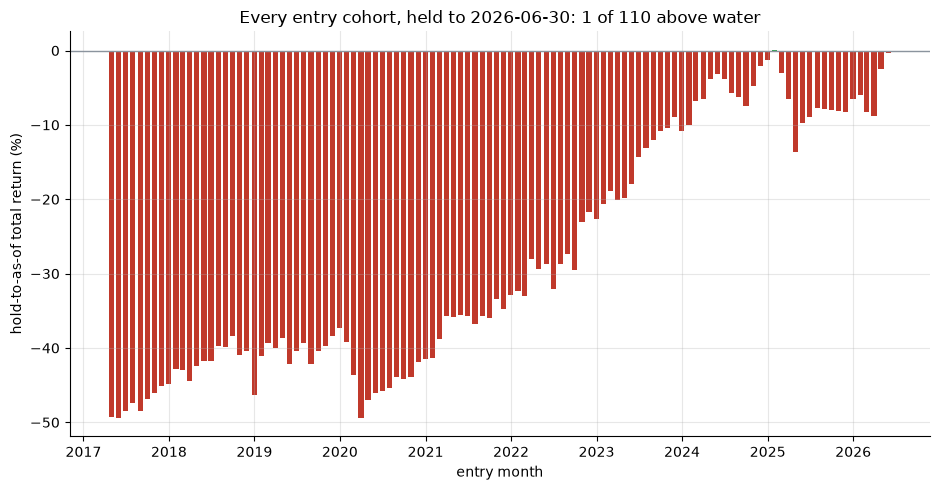

In [4]:
if HAVE_REAL:
    cv = st.covid_episode(TAPE); co = st.cohort_table(TAPE)
    print(f"2020: TAIL +{cv['tail_gain_pct']:.2f}% (to {cv['tail_peak_date']}) while SPY {cv['spy_fall_pct']:.2f}%")
    print(f"      given back by {cv['giveback_date']} ({cv['giveback_days']} days); day-one holder "
          f"{cv['holder_at_peak_pct']:+.2f}% at the peak -> {cv['holder_now_pct']:+.2f}% now")
    print(f"cohorts: {co['n_ahead_now']}/{co['n_cohorts']} ahead now (best {co['best_pct']:+.2f}% entered {co['best_date']}); "
          f"median {co['median_pct']:.1f}%; ever-ahead {co['share_ever_ahead']:.1f}%")
    tot = co['cohort_returns'] * 100
    fig, ax = plt.subplots()
    ax.bar(tot.index, tot.values, width=22, color=[GREEN if v > 0 else RED for v in tot.values])
    ax.axhline(0, color=GREY, lw=1)
    ax.set_ylabel('hold-to-as-of total return (%)'); ax.set_xlabel('entry month')
    ax.set_title(f"Every entry cohort, held to {R['end']}: {co['n_ahead_now']} of {co['n_cohorts']} above water")
    plt.tight_layout(); plt.show()
else:
    print('cache missing - frozen: 1/110 ahead, median', R['median'], '%, ever-ahead', R['ever_ahead'], '%')

> 💡 In plain words: the insurance **worked** — +28% while the market fell a third — and it still didn't pay. The bleed had eaten so much that a day-one holder was up only **+4.2%** at the very top, and **337 days** later the whole spike was gone. 72% of cohorts were ahead at *some* month-end; **1 of 110** is ahead today, by +0.1%, from a 2025 entry that never saw the crash. Net of the 2020 win: nobody.

### 4d · Tradability — the insurance inside a portfolio

The steelman for a permanent negative-carry hedge is portfolio-level: does the crash cushion buy back its bill? Monthly-rebalanced SPY/TAIL blends, 5 bps one-way × turnover:

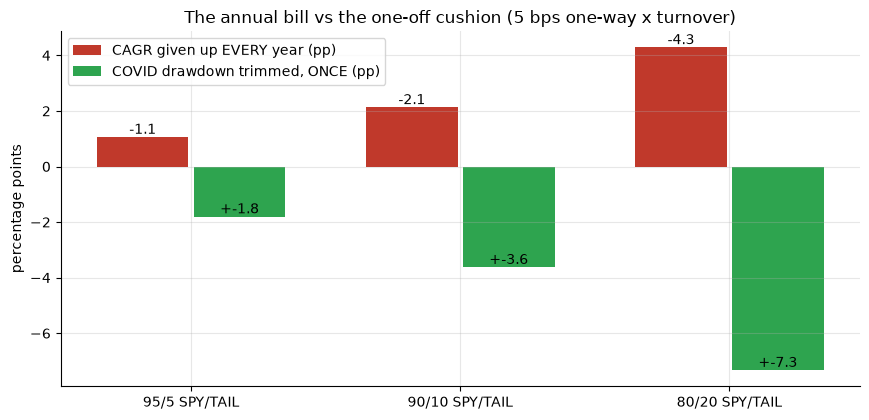

95/5: CAGR +14.06% vs SPY +15.12% (drag 1.06 pp/yr) | maxDD -22.9% vs -23.9% | COVID DD -17.6% vs -19.4%
90/10: CAGR +12.99% vs SPY +15.12% (drag 2.13 pp/yr) | maxDD -21.9% vs -23.9% | COVID DD -15.8% vs -19.4%
80/20: CAGR +10.84% vs SPY +15.12% (drag 4.28 pp/yr) | maxDD -19.9% vs -23.9% | COVID DD -12.1% vs -19.4%


In [5]:
if HAVE_REAL:
    rows = [st.hedged_portfolio(TAPE, w_tail=w, cost_bps=5.0) for w in (0.05, 0.10, 0.20)]
    blends = [(int(r['w_tail']*100), r['port_cagr_pct'], r['spy_cagr_pct'], r['cagr_drag_pct'],
               r['port_mdd_pct'], r['spy_mdd_pct'], r['port_covid_dd_pct'], r['spy_covid_dd_pct']) for r in rows]
else:
    blends = R['blends']
x = np.arange(3); drag = [b[3] for b in blends]; cushion = [b[7]-b[6] for b in blends]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-.18, drag, .34, color=RED, label='CAGR given up EVERY year (pp)')
ax.bar(x+.18, cushion, .34, color=GREEN, label='COVID drawdown trimmed, ONCE (pp)')
for i in x:
    ax.annotate(f'-{drag[i]:.1f}', (i-.18, drag[i]), ha='center', va='bottom')
    ax.annotate(f'+{cushion[i]:.1f}', (i+.18, cushion[i]), ha='center', va='bottom')
ax.set_xticks(x); ax.set_xticklabels([f'{100-b[0]}/{b[0]} SPY/TAIL' for b in blends])
ax.set_ylabel('percentage points'); ax.legend()
ax.set_title('The annual bill vs the one-off cushion (5 bps one-way x turnover)')
plt.tight_layout(); plt.show()
for b in blends: print(f'{100-b[0]}/{b[0]}: CAGR {b[1]:+.2f}% vs SPY {b[2]:+.2f}% (drag {b[3]:.2f} pp/yr) | '
                       f'maxDD {b[4]:.1f}% vs {b[5]:.1f}% | COVID DD {b[6]:.1f}% vs {b[7]:.1f}%')

> 💡 In plain words: a 90/10 blend gave up **2.1 pp of CAGR every year** to trim the COVID drawdown by **-3.6 pp once** (and max drawdown by -2.0 pp). Every blend ends behind 100% SPY over the fund's life. The long side has no deployable edge — **Mirage** — while the *short* side of the identical premium carried the desk's Real stamps in 92/63 (themselves only Fragile, because crash risk cuts the other way).

### 4e · Faithful-engine control — fair insurance vs a planted bleed (20 seeds)

Synthetic bond+put world. With `bleed = 0` the puts are actuarially **fair** (expected jump payoffs exactly repay the premium): the alpha detector must stay quiet. A planted 5%/yr bleed must be recovered in size and flagged in every seed. Never cited for a stamp.

planted bleed 0%/yr: mean alpha -0.21%/yr  mean HAC t -0.31  flagged 5% of 20 seeds
planted bleed 5%/yr: mean alpha -5.21%/yr  mean HAC t -5.81  flagged 100% of 20 seeds


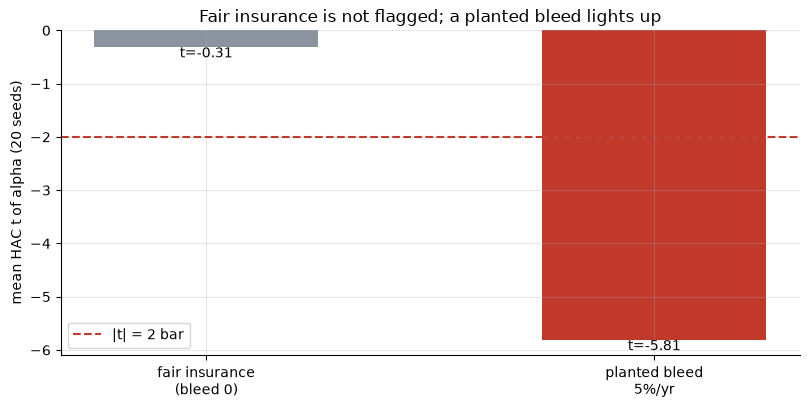

In [6]:
rows = st.control_summary(data.synthetic_world, bleeds=(0.0, 0.05), n_seeds=20)
for r in rows:
    print(f"planted bleed {r['bleed_pct']:.0f}%/yr: mean alpha {r['mean_alpha_ann_pct']:+.2f}%/yr  "
          f"mean HAC t {r['mean_t']:+.2f}  flagged {r['share_flagged']:.0f}% of {r['n_seeds']} seeds")
fig, ax = plt.subplots(figsize=(8.2, 4.2))
labs = [f"fair insurance\n(bleed 0)", f"planted bleed\n5%/yr"]
ax.bar(labs, [r['mean_t'] for r in rows], color=[GREY, RED], width=.5)
ax.axhline(-2, ls='--', c=RED, label='|t| = 2 bar')
for i, r in enumerate(rows): ax.annotate(f"t={r['mean_t']:.2f}", (i, r['mean_t']), ha='center', va='top')
ax.set_ylabel('mean HAC t of alpha (20 seeds)'); ax.legend()
ax.set_title('Fair insurance is not flagged; a planted bleed lights up')
plt.tight_layout(); plt.show()

> 💡 In plain words: when insurance is priced **fairly** the engine finds nothing (mean t = -0.31, 5% flagged — the nominal false-positive rate); a planted 5%/yr bleed is recovered at -5.21%/yr with mean t = -5.81, flagged in 100% of seeds. The real-tape −7.7%/yr at t = -3.28 is a measurement, not an artefact. *(Machinery proof only.)*

## 5 · The verdict

- **Signal `REAL`** — three independent clears on the real tape: monthly drift **-56.5 bps/mo** (HAC t = -2.17); monthly alpha vs its own collateral **-7.69%/yr** (HAC **t = -3.28**, negative in both crash-free sub-periods); buyer-side variance premium **-0.95 var pts/yr** over 401 months (HAC **t = -3.12**; vol-points t = -9.42). Survivorship runs against the claim and it clears anyway.
- **Tradability `MIRAGE`** — for the buyer: $1 → $0.50 net of fee; blends drag 1.1–4.3 pp/yr at 5 bps for a one-off cushion; the jackpot lasted 337 days. The harvestable side is the seller's ([92](../../92-easy-money/), [63](../../63-free-fall/) — Real / Fragile).
- **2020 win kept? `BUSTED`** — 1 of 110 cohorts ahead (+0.1%, 2025 entry); day-one holder peaked at +4.2%; 72% were ahead mid-flight and all gave it back.

## 6 · Going further

- **Both ends of the pipe now agree.** Short side: [92-easy-money](../../92-easy-money/) (+14.8%/yr shorting VIXY, HAC t = +2.31) and [63-free-fall](../../63-free-fall/) (SVXY +11.8%/yr). Long side (here): −7.7%/yr alpha on the live long-vol fund. One premium, two NAVs, opposite signs — the volatility risk premium triangulated on tradable products.
- **The signal axis is separate.** [86-tail-radar](../../86-tail-radar/) showed the *price* of tails (SKEW) does not predict crashes — so "buy insurance only when it's about to pay" has no documented trigger. Without timing, the carry math here is the whole story.
- **The honest use-case.** A permanent tail sleeve is a *utility* purchase (sleep, mandate constraints, leverage room), not an investment: budget it like an expense — ≈7.7%/yr of the sleeve — and expect the cohort table, not the 2020 poster.

*The reproducible core is offline and deterministic; buy-and-hold is static (no lag), the variance series uses strictly prior-month VIX (one documented lag). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*